In [1]:
import cv2, os, time
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

%matplotlib inline

In [6]:
labels_dir = "../data/mobile detection.v16i.yolov11/train/labels"
labels = os.listdir(labels_dir)
total_train = len(labels)

counts = [0] * 4
for label in labels:
    with open(os.path.join(labels_dir, label)) as file:
        for line in file:
            class_label = int(line.split(" ")[0])
            counts[class_label] += 1

print(counts)



[7238, 2505, 5664, 1959]


In [11]:
labels_dir = "../data/mobile detection.v16i.yolov11/test/labels"
labels = os.listdir(labels_dir)
total_train = len(labels)

counts = [0] * 4
for label in labels:
    with open(os.path.join(labels_dir, label)) as file:
        for line in file:
            class_label = int(line.split(" ")[0])
            counts[class_label] += 1

print(counts)


[364, 127, 299, 104]


Text(0.5, 1.0, 'Class Count')

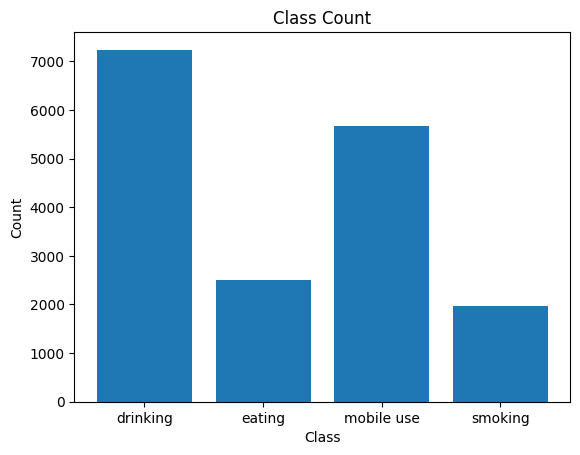

In [8]:
categories = ['drinking', 'eating', 'mobile use', 'smoking']
plt.bar(categories, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Count")

In [2]:
model_names = ["yolov8l", "yolov8m", "yolo11s", "yolo11m"]

model_weights = [
    "yolo8/yolov8l/weights/best.pt", 
    "yolo8/yolov8m/weights/best.pt", 
    "yolo11/yolo11s/weights/best.pt", 
    "yolo11/yolo11m/weights/best.pt"
]

In [2]:
dataset_path = "../data/mobile detection.v16i.yolov11/data.yaml"
model = YOLO("gen2/yolov11m_no_pretrain_365/weights/last.pt")

https://docs.ultralytics.com/guides/yolo-data-augmentation/#hue-adjustment-hsv_h
Ultralyics already has augmentation. I am just going to turn up the notch
* Hue:          0.15 -> 0.75
* Saturation:   0.75 -> 1
* rotation:     0 -> 180
* shear:        0 -> 10


In [3]:
epochs=35
imgsz=640
batch=8
hsv_h=0.75
hsv_s=1.0
rotation=180
shear=10
close_mosaic=5


In [5]:

model.train(data=dataset_path, 
            batch=batch,
            imgsz=imgsz,
            epochs=epochs,
            hsv_h=hsv_h, 
            hsv_s=hsv_s, 
            degrees=rotation,
            shear=shear,
            project="gen2",
#            close_mosaic=close_mosaic,
            name="yolov11m_no_pretrain_400")

New https://pypi.org/project/ultralytics/8.3.217 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.209 🚀 Python-3.12.3 torch-2.10.0.dev20251008+rocm7.0 CUDA:0 (AMD Radeon RX 7800 XT, 16368MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/mobile detection.v16i.yolov11/data.yaml, degrees=180, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.75, hsv_s=1.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=gen2/yolov11m_no_pretrain_365/weights/last.pt, momentum=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd42b450d10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
#AFter 50 epochs
#             Images      Instances      Box(P          R      mAP50      mAP50-95)
# all        524             526          0.616      0.579      0.626      0.282
# after 100 epochs
# all        524              526         0.841      0.796      0.851      0.435
# after 150                                                                0.47
# after 200                                                                 .505
# 250                                                                    0.519432593444703,
#300                                                                    0.5158696083654243,
#350                                                                    0.520
#                                                                         .547
#400                                                                    .555